<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/RREF_%26_NEWTON_RAPHSON_TECH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First, let's understand the concept. A system of linear equations can be represented as an augmented matrix. To solve it using the Reduced Row Echelon Form (RREF), we perform elementary row operations until:

1.  Each leading entry (the first non-zero number from the left, also called a pivot) of a non-zero row is 1.
2.  Each column containing a leading entry has zeros everywhere else.
3.  Each leading entry is to the right of the leading entry of the row above it.
4.  All rows consisting entirely of zeros are at the bottom of the matrix.

Once the matrix is in RREF, the solution to the system of equations can be directly read from the last column.

In [ ]:
import numpy as np

def rref(matrix):
    """
    Converts a matrix to its Reduced Row Echelon Form (RREF).
    Args:
        matrix (np.array): The augmented matrix representing the system.

    Returns:
        np.array: The matrix in RREF.
    """
    # Make a copy to avoid modifying the original matrix
    mat = np.array(matrix, dtype=float)
    rows, cols = mat.shape
    lead = 0

    for r in range(rows):
        if lead >= cols: # If we have gone past the last column for pivots
            break
        i = r
        while i < rows and mat[i, lead] == 0:
            i += 1
        if i == rows:
            lead += 1 # Move to the next column if no pivot in current column below r
            continue

        # Swap rows to bring the pivot to the current row 'r'
        mat[[i, r]] = mat[[r, i]]

        # Scale the pivot row to make the leading entry 1
        lv = mat[r, lead] # Leading value
        mat[r, :] = mat[r, :] / lv

        # Eliminate other entries in the current pivot column
        for i in range(rows):
            if i != r:
                lv = mat[i, lead]
                mat[i, :] = mat[i, :] - lv * mat[r, :]
        lead += 1 # Move to the next pivot column

    return mat

# Example usage:
# Solve the system:
# x + 2y - z = -4
# 2x + y + z = 1
# 3x + 3y + 2z = 7

# Augmented matrix [A | b]
A = np.array([
    [1, 2, -1, -4],
    [2, 1, 1, 1],
    [3, 3, 2, 7]
])

print("Original Augmented Matrix:")
print(A)
print("\n")

rref_matrix = rref(A)

print("Reduced Row Echelon Form (RREF):")
print(rref_matrix)
print("\n")

# Extract the solution from the last column if a unique solution exists
# (i.e., if the left part of RREF is an identity matrix)
if np.allclose(rref_matrix[:, :-1], np.identity(A.shape[0])):
    solution = rref_matrix[:, -1]
    print("Solution (x, y, z):")
    print(solution)
else:
    print("The system does not have a unique solution (e.g., no solution or infinitely many solutions).")


Original Augmented Matrix:
[[ 1  2 -1 -4]
 [ 2  1  1  1]
 [ 3  3  2  7]]


Reduced Row Echelon Form (RREF):
[[ 1.  0.  0. -3.]
 [ 0.  1.  0.  2.]
 [ 0.  0.  1.  5.]]


Solution (x, y, z):
[-3.  2.  5.]


### Calculating Eigenvalues and Eigenvectors

Eigenvectors are special non-zero vectors that, when multiplied by a matrix, result in a scaled version of themselves. The scaling factor is called the eigenvalue.

For a square matrix `A`, a vector `v` is an eigenvector if it satisfies the equation:

`Av = λv`

where `λ` (lambda) is a scalar called the eigenvalue corresponding to the eigenvector `v`.

Let's use NumPy to find the eigenvalues and eigenvectors of a sample matrix.

In [ ]:
import numpy as np

# Define a sample square matrix
A_eigen = np.array([
    [1, 2, -1, -4],
    [2, 1, 1, 1],
    [3, 3, 2, 7],
    [0, 0, 0, 0]
])

print("Original Matrix A:")
print(A_eigen)
print("\n")

# Calculate eigenvalues and eigenvectors
# eigvals will be the eigenvalues
# eigvecs will be a matrix where columns are the eigenvectors
eigvals, eigvecs = np.linalg.eig(A_eigen)

print("Eigenvalues:")
print(eigvals)
print("\n")

print("Eigenvectors (columns of this matrix):")
print(eigvecs)
print("\n")

# You can verify each eigenvector-eigenvalue pair:
print("Verification:")
for i in range(len(eigvals)):
    eigenvalue = eigvals[i]
    eigenvector = eigvecs[:, i]

    print(f"For Eigenvalue {eigenvalue:.4f}:")
    print(f"  A @ v = {A_eigen @ eigenvector}")
    print(f"  λ * v = {eigenvalue * eigenvector}")
    print(f"  Are they approximately equal? {np.allclose(A_eigen @ eigenvector, eigenvalue * eigenvector)}\n")


Original Matrix A:
[[ 1  2 -1 -4]
 [ 2  1  1  1]
 [ 3  3  2  7]
 [ 0  0  0  0]]


Eigenvalues:
[ 3.  2. -1.  0.]


Eigenvectors (columns of this matrix):
[[ 7.66964989e-02 -3.01511345e-01  7.07106781e-01  4.80384461e-01]
 [-3.83482494e-01  3.01511345e-01 -7.07106781e-01 -3.20256308e-01]
 [-9.20357987e-01  9.04534034e-01  2.28751291e-16 -8.00640769e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.60128154e-01]]


Verification:
For Eigenvalue 3.0000:
  A @ v = [ 0.2300895  -1.15044748 -2.76107396  0.        ]
  λ * v = [ 0.2300895  -1.15044748 -2.76107396  0.        ]
  Are they approximately equal? True

For Eigenvalue 2.0000:
  A @ v = [-0.60302269  0.60302269  1.80906807  0.        ]
  λ * v = [-0.60302269  0.60302269  1.80906807  0.        ]
  Are they approximately equal? True

For Eigenvalue -1.0000:
  A @ v = [-7.07106781e-01  7.07106781e-01 -4.44089210e-16  0.00000000e+00]
  λ * v = [-7.07106781e-01  7.07106781e-01 -2.28751291e-16 -0.00000000e+00]
  Are they approximatel

### 3D Visualization of Eigenvectors (Approximation)

As mentioned, the eigenvectors for a 4x4 matrix exist in a 4-dimensional space, which cannot be directly visualized in 3D. To provide a visual representation, we will plot the first three components (x, y, z) of each eigenvector as a vector originating from the origin (0,0,0). This serves as an approximation, allowing us to observe their relative orientations in a 3D subspace.

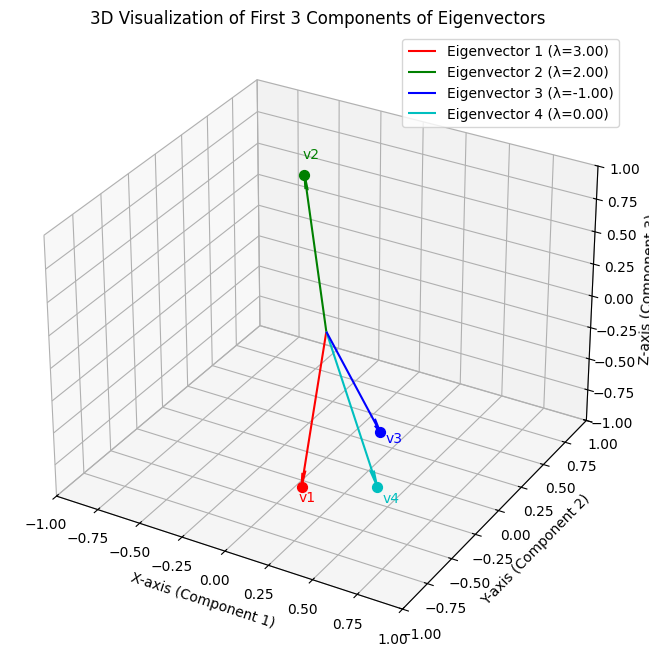

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Assuming eigvecs and eigvals are available from the previous execution
# If not, you might need to re-run the cell that defines A_eigen and calculates them.

# A_eigen, eigvals, eigvecs are available in the kernel from cell 918873f8

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = ['r', 'g', 'b', 'c'] # Colors for each eigenvector

# Plot each eigenvector as an arrow from the origin
for i in range(eigvecs.shape[1]):
    # Take the first three components for 3D visualization
    vec = eigvecs[:3, i]
    eigenvalue = eigvals[i]

    # Plot the vector as an arrow
    ax.quiver(0, 0, 0, vec[0], vec[1], vec[2],
              color=colors[i], length=np.linalg.norm(vec), normalize=False,
              arrow_length_ratio=0.1, label=f'Eigenvector {i+1} (λ={eigenvalue:.2f})')

    # Add a point at the end of the vector for clarity
    ax.scatter(vec[0], vec[1], vec[2], color=colors[i], marker='o', s=50)
    ax.text(vec[0] * 1.1, vec[1] * 1.1, vec[2] * 1.1, f'v{i+1}', color=colors[i])


ax.set_xlabel('X-axis (Component 1)')
ax.set_ylabel('Y-axis (Component 2)')
ax.set_zlabel('Z-axis (Component 3)')
ax.set_title('3D Visualization of First 3 Components of Eigenvectors')
ax.legend()
ax.grid(True)

# Set equal aspect ratio to make it look proportional
# This might not work perfectly with quiver, but helps scale the axes
max_range = np.array([eigvecs[:3,:].max() - eigvecs[:3,:].min()]).max() / 2.0
mid_x = (eigvecs[:3,0].max() + eigvecs[:3,0].min()) * 0.5
mid_y = (eigvecs[:3,1].max() + eigvecs[:3,1].min()) * 0.5
mid_z = (eigvecs[:3,2].max() + eigvecs[:3,2].min()) * 0.5
# If we want to center around origin for eigenvectors, better to define a cube around 0
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_zlim([-1, 1])

plt.show()


Let's try another example, a system with infinite solutions:

**System:**
x + y + z = 3
2x + 2y + 2z = 6
3x + 3y + 3z = 9

In [ ]:
A_infinite = np.array([
    [1, 1, 1, 3],
    [2, 2, 2, 6],
    [3, 3, 3, 9]
])

print("Original Augmented Matrix (Infinite Solutions):")
print(A_infinite)
print("\n")

rref_infinite = rref(A_infinite)

print("Reduced Row Echelon Form (RREF) for Infinite Solutions:")
print(rref_infinite)
print("\n")

# For systems with infinite solutions, you typically express variables in terms of free variables.
# In this RREF, you can see that the solution would involve free variables (e.g., y and z could be free variables
# and x expressed in terms of them).

Original Augmented Matrix (Infinite Solutions):
[[1 1 1 3]
 [2 2 2 6]
 [3 3 3 9]]


Reduced Row Echelon Form (RREF) for Infinite Solutions:
[[1. 1. 1. 3.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]




The **Newton-Raphson method** is an iterative numerical technique used to find successively better approximations to the roots (or zeroes) of a real-valued function. It starts with an initial guess and then uses the function's value and its derivative at that guess to find a new, hopefully better, guess. The formula for the next approximation $x_{n+1}$ from the current approximation $x_n$ is:

$$x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}$$

Where:
- $f(x_n)$ is the value of the function at $x_n$.
- $f'(x_n)$ is the value of the derivative of the function at $x_n$.

This process is repeated until the difference between successive approximations is smaller than a specified tolerance, or a maximum number of iterations is reached.

In [ ]:
import numpy as np

def newton_raphson(f, df, x0, tol=1e-6, max_iter=100):
    """
    Finds a root of a function using the Newton-Raphson method.

    Args:
        f (function): The function for which to find the root.
        df (function): The derivative of the function f.
        x0 (float): The initial guess for the root.
        tol (float, optional): The tolerance for convergence. Defaults to 1e-6.
        max_iter (int, optional): The maximum number of iterations. Defaults to 100.

    Returns:
        float: The approximated root.
        None: If the method does not converge within max_iter.
    """
    x = x0
    for i in range(max_iter):
        f_val = f(x)
        df_val = df(x)

        if abs(df_val) < 1e-10:  # Avoid division by zero or very small derivative
            print("Derivative is too small. No convergence or multiple roots.")
            return None

        x_new = x - f_val / df_val

        if abs(x_new - x) < tol:
            print(f"Converged in {i+1} iterations.")
            return x_new
        x = x_new

    print(f"Did not converge within {max_iter} iterations.")
    return None

# Example Usage:
# Find the root of f(x) = x^3 - 2x - 5

def f(x):
    return x**3 - 2*x - 5

def df(x):
    return 3*x**2 - 2

# Initial guess
x0 = 100

print(f"Finding root for f(x) = x^3 - 2x - 5 with initial guess x0 = {x0}")
root = newton_raphson(f, df, x0)

if root is not None:
    print(f"Approximated root: {root:.6f}")
    print(f"f({root:.6f}) = {f(root):.6e}")

print("\n" + "-"*30 + "\n")

# Another Example: Finding a root of cos(x) - x
def g(x):
    return np.cos(x) - x

def dg(x):
    return -np.sin(x) - 1

x0_g = 0.5

print(f"Finding root for g(x) = cos(x) - x with initial guess x0 = {x0_g}")
root_g = newton_raphson(g, dg, x0_g)

if root_g is not None:
    print(f"Approximated root: {root_g:.6f}")
    print(f"g({root_g:.6f}) = {g(root_g):.6e}")


Finding root for f(x) = x^3 - 2x - 5 with initial guess x0 = 100
Converged in 14 iterations.
Approximated root: 2.094551
f(2.094551) = 6.838974e-14

------------------------------

Finding root for g(x) = cos(x) - x with initial guess x0 = 0.5
Converged in 4 iterations.
Approximated root: 0.739085
g(0.739085) = 0.000000e+00


### 3D Visualization of Newton-Raphson Iterative Path

This visualization will plot the progress of the Newton-Raphson method in a 3D space. The axes will represent:
- **X-axis:** The iteration number
- **Y-axis:** The current approximation of the root ($x_n$)
- **Z-axis:** The function value at that approximation ($f(x_n)$)

This will show the 'path' the algorithm takes from the initial guess towards the root.

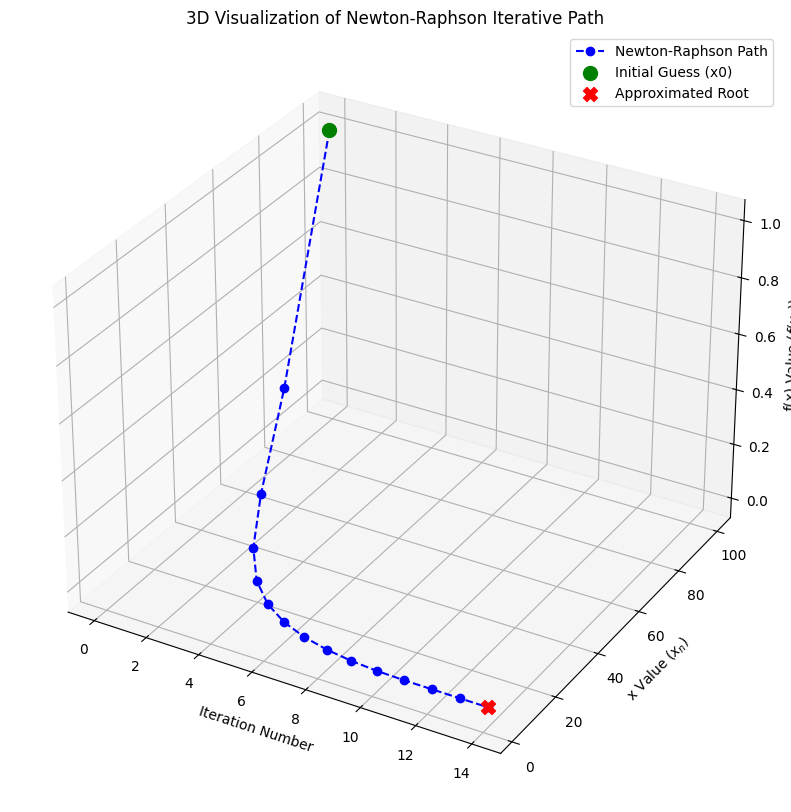

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Redefine the function (f(x) and df(x) are already in kernel from previous runs)
def f(x):
    return x**3 - 2*x - 5

# Get the history of x values from the previous visualization cell (eb6425f1)
# If you ran that cell, 'x_iterations' should be available.
# If not, you might need to re-run the newton_raphson_visual function.

# Ensure x_iterations is available, or re-run the function to get it
# For robustness, we can re-call the function, assuming 'x0_plot' is still in scope.
# If 'x_iterations' was cleared from memory, this ensures it's recalculated.
def newton_raphson_visual(f, df, x0, tol=1e-6, max_iter=100):
    x_history = [x0]
    x = x0
    for i in range(max_iter):
        f_val = f(x)
        df_val = df(x)
        if abs(df_val) < 1e-10:
            break
        x_new = x - f_val / df_val
        x_history.append(x_new)
        if abs(x_new - x) < tol:
            break
        x = x_new
    return np.array(x_history)

# Assuming df is available from previous code or redefine for clarity
def df(x):
    return 3*x**2 - 2
x0_plot = 100 # Assuming initial guess is still 100
x_iterations = newton_raphson_visual(f, df, x0_plot)


# Prepare data for 3D plot
iteration_numbers = np.arange(len(x_iterations))
x_values = x_iterations
f_x_values = f(x_iterations)

# Create the 3D plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the trajectory
ax.plot(iteration_numbers, x_values, f_x_values, marker='o', linestyle='--', color='blue', label='Newton-Raphson Path')

# Mark the start and end points
ax.scatter(iteration_numbers[0], x_values[0], f_x_values[0], color='green', s=100, label='Initial Guess (x0)')
ax.scatter(iteration_numbers[-1], x_values[-1], f_x_values[-1], color='red', s=100, label='Approximated Root', marker='X')

# Add labels and title
ax.set_xlabel('Iteration Number')
ax.set_ylabel('x Value ($x_n$)')
ax.set_zlabel('f(x) Value ($f(x_n)$)')
ax.set_title('3D Visualization of Newton-Raphson Iterative Path')
ax.legend()
ax.grid(True)

plt.show()


Let's visualize how the Newton-Raphson method works. We'll plot the function $f(x) = x^3 - 2x - 5$ and its derivative, and then trace the iterative steps from the initial guess to the approximated root. Each step involves drawing a tangent line at the current approximation and finding its intersection with the x-axis to get the next approximation.

Converged in 14 iterations for visualization.


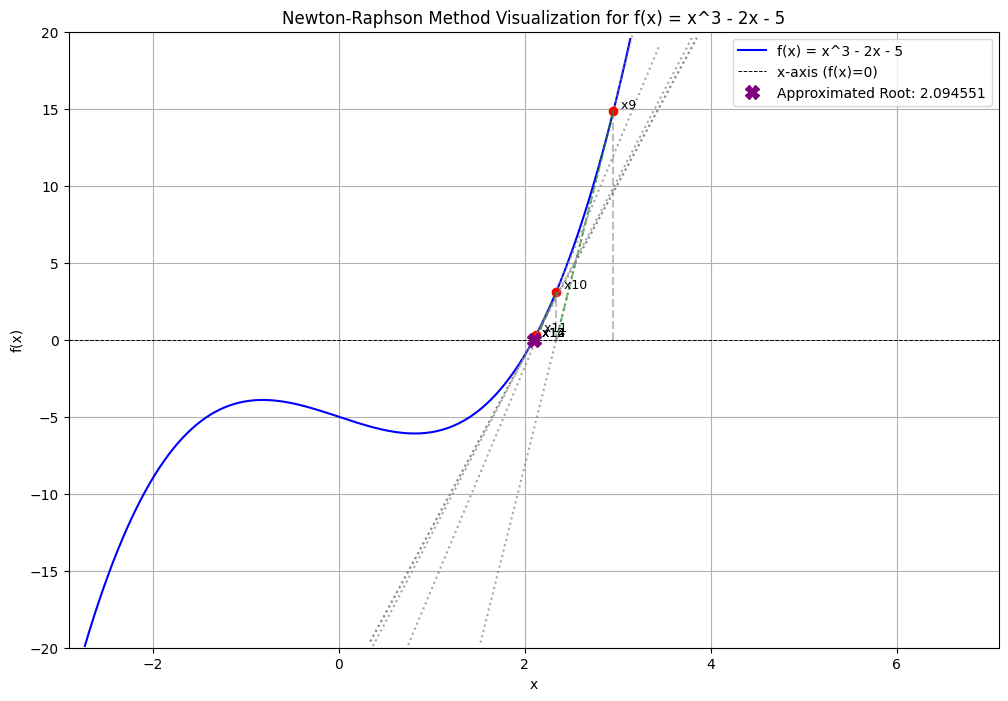

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Redefine the function and its derivative for plotting
def f(x):
    return x**3 - 2*x - 5

def df(x):
    return 3*x**2 - 2

# Newton-Raphson function modified to store iterations
def newton_raphson_visual(f, df, x0, tol=1e-6, max_iter=100):
    x_history = [x0]
    x = x0
    for i in range(max_iter):
        f_val = f(x)
        df_val = df(x)

        if abs(df_val) < 1e-10:
            print("Derivative is too small. Stopping visualization.")
            break

        x_new = x - f_val / df_val
        x_history.append(x_new)

        if abs(x_new - x) < tol:
            print(f"Converged in {i+1} iterations for visualization.")
            break
        x = x_new
    else:
        print(f"Did not converge within {max_iter} iterations for visualization.")
    return np.array(x_history)

# Initial guess from the previous execution
x0_plot = 100

# Get the history of x values during convergence
x_iterations = newton_raphson_visual(f, df, x0_plot)

# --- Define visualization window limits explicitly to prevent large image size ---
# Focus on a reasonable range around the final root for visualization
root_approx = x_iterations[-1]
vis_xmin = root_approx - 5
vis_xmax = root_approx + 5
vis_ymin = -20
vis_ymax = 20

# If the initial guess is relatively close, expand the x-range slightly to include it
# Otherwise, for very distant x0, just show the convergence region around the root
if abs(x0_plot - root_approx) < 20: # Arbitrary threshold for 'close enough' to include initial guess
    vis_xmin = min(vis_xmin, x0_plot - 5)
    vis_xmax = max(vis_xmax, x0_plot + 5)

# Generate x-values for the main function plot within the *desired visualization window*
x_vals_for_plot = np.linspace(vis_xmin, vis_xmax, 400)
y_vals_for_plot = f(x_vals_for_plot)

plt.figure(figsize=(12, 8))

# Plot the function, filtering points that fall outside the y-limits
mask_f_visible = (y_vals_for_plot >= vis_ymin) & (y_vals_for_plot <= vis_ymax)
plt.plot(x_vals_for_plot[mask_f_visible], y_vals_for_plot[mask_f_visible], label='f(x) = x^3 - 2x - 5', color='blue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.7, label='x-axis (f(x)=0)')

# Plotting iterations
for i in range(len(x_iterations)):
    x_current = x_iterations[i]
    f_current = f(x_current)

    # Only plot current point marker and text if it's within the visualization window
    if vis_xmin <= x_current <= vis_xmax and vis_ymin <= f_current <= vis_ymax:
        plt.plot(x_current, f_current, 'o', color='red', markersize=6)
        plt.text(x_current, f_current, f'  x{i}', verticalalignment='bottom' if f_current > 0 else 'top', fontsize=9)

    # Plot tangent line and step only if current point is visible AND not the last iteration
    if i < len(x_iterations) - 1:
        x_next = x_iterations[i+1]
        # Only draw tangent related lines if current point is within the visible y range
        if vis_xmin <= x_current <= vis_xmax and vis_ymin <= f_current <= vis_ymax:
            # Generate local x-range for tangent line around x_current
            tangent_line_x_coords = np.linspace(x_current - 2, x_current + 2, 50)
            # Clip tangent x-range to overall visualization x-limits
            tangent_line_x_coords = np.clip(tangent_line_x_coords, vis_xmin, vis_xmax)
            tangent_line_y_coords = df(x_current) * (tangent_line_x_coords - x_current) + f_current

            # Filter tangent line points to be within y-limits before plotting
            mask_tangent_visible = (tangent_line_y_coords >= vis_ymin) & (tangent_line_y_coords <= vis_ymax)
            if np.any(mask_tangent_visible):
                plt.plot(tangent_line_x_coords[mask_tangent_visible], tangent_line_y_coords[mask_tangent_visible], linestyle=':', color='gray', alpha=0.7)

            # Plot vertical line from current point to x-axis
            plt.plot([x_current, x_current], [0, f_current], linestyle='--', color='gray', alpha=0.5)

            # Plot line from current point on curve to next approximation on x-axis
            # Ensure the next point is also within the x-range for drawing this connecting line
            if vis_xmin <= x_next <= vis_xmax:
                plt.plot([x_current, x_next], [f_current, 0], linestyle='--', color='green', alpha=0.5)


# Plot initial guess and final root markers, if they are within the visible window
if vis_xmin <= x_iterations[0] <= vis_xmax and vis_ymin <= f(x_iterations[0]) <= vis_ymax:
    plt.plot(x_iterations[0], f(x_iterations[0]), 'o', color='orange', markersize=8, label=f'Initial Guess: x0={x0_plot}')

if vis_xmin <= x_iterations[-1] <= vis_xmax and vis_ymin <= f(x_iterations[-1]) <= vis_ymax:
    plt.plot(x_iterations[-1], f(x_iterations[-1]), 'X', color='purple', markersize=10, label=f'Approximated Root: {x_iterations[-1]:.6f}')


plt.title('Newton-Raphson Method Visualization for f(x) = x^3 - 2x - 5')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.ylim(vis_ymin, vis_ymax) # Set final y-limit
plt.xlim(vis_xmin, vis_xmax) # Set final x-limit
plt.show()